# 05 - Evaluation & Benchmarking

Comprehensive evaluation of ModernBERT-RGAT on SemEval restaurant datasets:

1. Setup & load checkpoints
2. Per-dataset evaluation (2014, 2015, 2016)
3. ATE metrics (strict, partial, token-level F1)
4. ASC metrics (accuracy, per-class F1, confusion matrices)
5. Error analysis
6. SOTA comparison
7. Save results

---

## 1. Setup & Imports

In [1]:
import subprocess, sys, os

def install_if_missing(package, pip_name=None):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name or package])

install_if_missing('sklearn', 'scikit-learn')
install_if_missing('transformers', 'transformers')
install_if_missing('spacy', 'spacy')
install_if_missing('seaborn', 'seaborn')

import spacy
try:
    spacy.load('en_core_web_sm')
except OSError:
    subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'])

print('Dependencies ready.')

/home/thota23/miniconda3/envs/bash_ai_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dependencies ready.


In [2]:
PROJECT_ROOT = os.path.expanduser('~/SOTA-ModernBERT-RGAT-Joint-Aspect-Sentiment-Extraction-for-Food-Tech-Reviews')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import gc
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.model import ModernBERT_RGAT
from src.dataset import ABSAPreprocessor, create_dataloader
from src.data_pipeline import load_config, build_splits
from src.evaluator import (
    ModelEvaluator,
    get_sota_comparison_df,
    get_error_summary,
    get_sentiment_confusion_analysis,
    save_evaluation_results,
)

# Use GPU if available, otherwise CPU (evaluation needs far less memory than training)
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Using GPU: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    print('Using CPU (evaluation is lightweight, this is fine)')

print(f'PyTorch: {torch.__version__}')
print('Imports successful.')

Using GPU: NVIDIA H100 PCIe MIG 2g.20gb
PyTorch: 2.5.1+cu124
Imports successful.


In [3]:
config = load_config('configs/config.yaml')
preprocessor = ABSAPreprocessor(
    model_name=config['model']['backbone'],
    max_len=config['model']['max_len'],
)
label_map = config['labels']['polarity']
label_names = [name for name, _ in sorted(label_map.items(), key=lambda x: x[1])]

print(f'Labels: {label_names}')

# Check which checkpoints exist
ckpt_dir = config['training']['checkpoint_dir']
available_years = []
for year in ['2014', '2015', '2016']:
    ckpt_path = os.path.join(ckpt_dir, f'best_model_{year}.pt')
    if os.path.exists(ckpt_path):
        size_mb = os.path.getsize(ckpt_path) / (1024**2)
        available_years.append(year)
        print(f'  ✅ best_model_{year}.pt ({size_mb:.1f} MB)')
    else:
        print(f'  ❌ best_model_{year}.pt — NOT FOUND (will skip)')

print(f'\nDatasets to evaluate: {available_years}')

  Preprocessor initialized: answerdotai/ModernBERT-base, max_len=96
Labels: ['positive', 'negative', 'neutral', 'conflict']
  ✅ best_model_2014.pt (965.9 MB)
  ✅ best_model_2015.pt (965.9 MB)
  ✅ best_model_2016.pt (965.9 MB)

Datasets to evaluate: ['2014', '2015', '2016']


## 2. Evaluate All Datasets

In [4]:
all_results = {}

for year in available_years:
    print(f'\n{"="*60}')
    print(f'  Evaluating SemEval {year}')
    print(f'{"="*60}')
    
    # Load test data
    _, _, test_df = build_splits(config, year, verbose=False)
    test_loader = create_dataloader(
        test_df, preprocessor, label_map,
        batch_size=config['training']['eval_batch_size'],
        shuffle=False,
    )
    print(f'  Test samples: {len(test_df)}, Test batches: {len(test_loader)}')
    
    # Load model from checkpoint
    ckpt_path = os.path.join(ckpt_dir, f'best_model_{year}.pt')
    evaluator = ModelEvaluator.from_checkpoint(ckpt_path, config, device)
    
    # Run evaluation
    result = evaluator.evaluate(test_loader, dataset_year=year)
    all_results[year] = result
    
    # Print summary
    print(f'\n  --- ATE (Aspect Term Extraction) ---')
    print(f'  Strict  F1: {result.ate.strict_f1:.4f}  (P={result.ate.strict_precision:.4f}, R={result.ate.strict_recall:.4f})')
    print(f'  Partial F1: {result.ate.partial_f1:.4f}  (P={result.ate.partial_precision:.4f}, R={result.ate.partial_recall:.4f})')
    print(f'  Token   F1: {result.ate.token_f1:.4f}  (P={result.ate.token_precision:.4f}, R={result.ate.token_recall:.4f})')
    print(f'  Predicted spans: {result.ate.num_pred_spans}, Gold spans: {result.ate.num_gold_spans}')
    
    print(f'\n  --- ASC (Aspect Sentiment Classification) ---')
    print(f'  Accuracy:    {result.asc.accuracy:.4f}')
    print(f'  Macro F1:    {result.asc.macro_f1:.4f}')
    print(f'  Weighted F1: {result.asc.weighted_f1:.4f}')
    for cls_name, cls_f1 in result.asc.per_class_f1.items():
        print(f'    {cls_name:12s}: F1={cls_f1:.4f}')
    
    print(f'\n  --- Combined ---')
    print(f'  Combined F1: {result.combined_f1:.4f}')
    print(f'  Error count: {len(result.errors)}')
    
    # Clean up
    del evaluator
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f'\n{"="*60}')
print(f'  Evaluation complete for: {list(all_results.keys())}')
print(f'{"="*60}')


  Evaluating SemEval 2014
  Loaded cached splits from Data/cached/splits_d183f9c56713.pkl
  Test samples: 544, Test batches: 68


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 837.16it/s, Materializing param=layers.21.mlp_norm.weight]     
ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/thota23/SOTA-ModernBERT-RGAT-Joint-Aspect-Sentiment-Extraction-for-Food-Tech-Reviews/src/evaluator.py:308: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_o

  Loaded checkpoint: checkpoints/best_model_2014.pt
  Trained for 6 epochs
  Val ATE F1: 0.7935
  Val ASC F1: 0.6139

  --- ATE (Aspect Term Extraction) ---
  Strict  F1: 0.7835  (P=0.7894, R=0.7778)
  Partial F1: 0.8645  (P=0.8709, R=0.8581)
  Token   F1: 0.8722  (P=0.9419, R=0.8121)
  Predicted spans: 1472, Gold spans: 1494

  --- ASC (Aspect Sentiment Classification) ---
  Accuracy:    0.7610
  Macro F1:    0.5673
  Weighted F1: 0.7591
    positive    : F1=0.8788
    negative    : F1=0.6542
    neutral     : F1=0.5361
    conflict    : F1=0.2000

  --- Combined ---
  Combined F1: 0.6754
  Error count: 50

  Evaluating SemEval 2015
  Loaded cached splits from Data/cached/splits_a4c9870c2d77.pkl
  Test samples: 297, Test batches: 38


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 924.86it/s, Materializing param=layers.21.mlp_norm.weight]     
ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/thota23/SOTA-ModernBERT-RGAT-Joint-Aspect-Sentiment-Extraction-for-Food-Tech-Reviews/src/evaluator.py:308: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_o

  Loaded checkpoint: checkpoints/best_model_2015.pt
  Trained for 13 epochs
  Val ATE F1: 0.7913
  Val ASC F1: 0.7466

  --- ATE (Aspect Term Extraction) ---
  Strict  F1: 0.6796  (P=0.6831, R=0.6761)
  Partial F1: 0.7494  (P=0.7532, R=0.7455)
  Token   F1: 0.7561  (P=0.8292, R=0.6949)
  Predicted spans: 385, Gold spans: 389

  --- ASC (Aspect Sentiment Classification) ---
  Accuracy:    0.8384
  Macro F1:    0.5954
  Weighted F1: 0.8329
    positive    : F1=0.9008
    negative    : F1=0.7802
    neutral     : F1=0.1053

  --- Combined ---
  Combined F1: 0.6375
  Error count: 50

  Evaluating SemEval 2016
  Loaded cached splits from Data/cached/splits_ac7754739674.pkl
  Test samples: 344, Test batches: 43


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 858.27it/s, Materializing param=layers.21.mlp_norm.weight]     
ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/thota23/SOTA-ModernBERT-RGAT-Joint-Aspect-Sentiment-Extraction-for-Food-Tech-Reviews/src/evaluator.py:308: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_o

  Loaded checkpoint: checkpoints/best_model_2016.pt
  Trained for 12 epochs
  Val ATE F1: 0.7580
  Val ASC F1: 0.6659

  --- ATE (Aspect Term Extraction) ---
  Strict  F1: 0.6720  (P=0.6687, R=0.6755)
  Partial F1: 0.7790  (P=0.7751, R=0.7830)
  Token   F1: 0.7829  (P=0.8303, R=0.7405)
  Predicted spans: 498, Gold spans: 493

  --- ASC (Aspect Sentiment Classification) ---
  Accuracy:    0.8779
  Macro F1:    0.6528
  Weighted F1: 0.8720
    positive    : F1=0.9258
    negative    : F1=0.8421
    neutral     : F1=0.1905

  --- Combined ---
  Combined F1: 0.6624
  Error count: 50

  Evaluation complete for: ['2014', '2015', '2016']


## 3. Results Summary Table

In [5]:
summary_rows = []
for year, result in all_results.items():
    summary_rows.append({
        'Dataset': f'SemEval {year}',
        'ATE Strict F1': f'{result.ate.strict_f1:.4f}',
        'ATE Partial F1': f'{result.ate.partial_f1:.4f}',
        'ATE Token F1': f'{result.ate.token_f1:.4f}',
        'ASC Accuracy': f'{result.asc.accuracy:.4f}',
        'ASC Macro F1': f'{result.asc.macro_f1:.4f}',
        'Combined F1': f'{result.combined_f1:.4f}',
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    display(summary_df.style.set_caption('ModernBERT-RGAT Evaluation Results'))
else:
    print('No results available. Train models first using 04_training.ipynb.')

,Dataset,ATE Strict F1,ATE Partial F1,ATE Token F1,ASC Accuracy,ASC Macro F1,Combined F1
0,SemEval 2014,0.7835,0.8645,0.8722,0.7610,0.5673,0.6754
1,SemEval 2015,0.6796,0.7494,0.7561,0.8384,0.5954,0.6375
2,SemEval 2016,0.6720,0.7790,0.7829,0.8779,0.6528,0.6624


## 4. Confusion Matrices

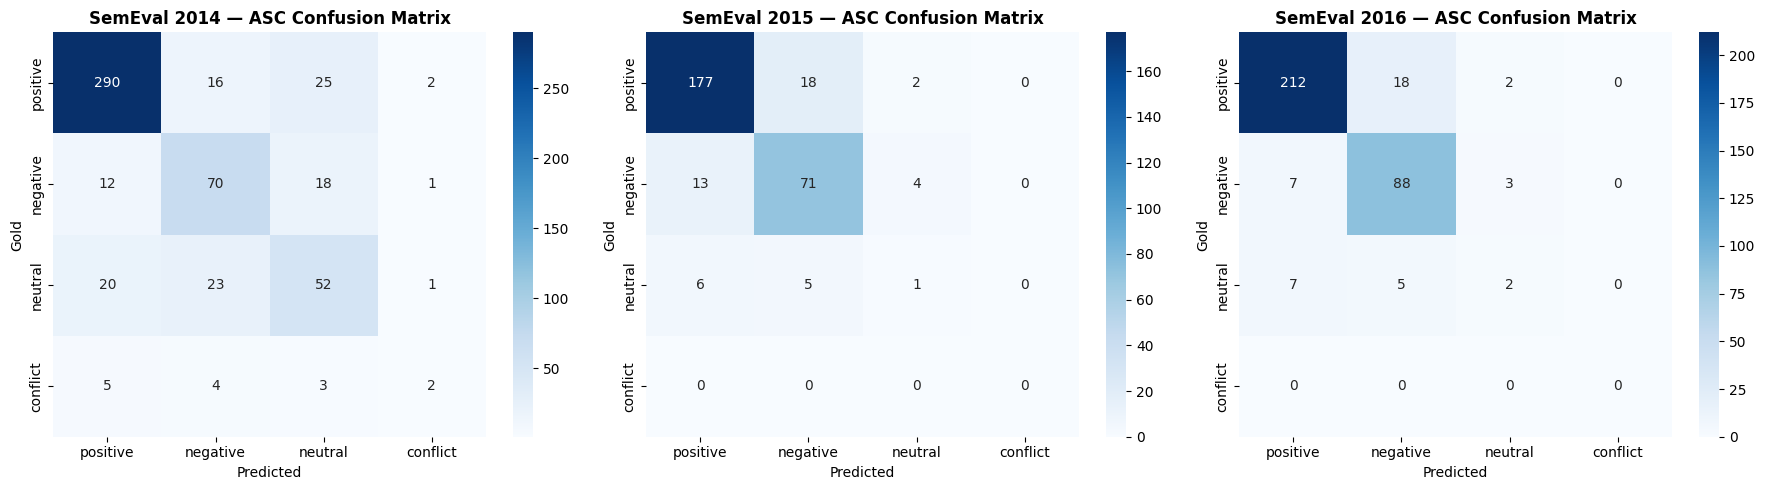

In [6]:
if all_results:
    n_datasets = len(all_results)
    fig, axes = plt.subplots(1, n_datasets, figsize=(6 * n_datasets, 5))
    if n_datasets == 1:
        axes = [axes]
    
    for ax, (year, result) in zip(axes, all_results.items()):
        cm = result.asc.confusion_matrix
        if cm is not None:
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                ax=ax, cbar=True,
            )
            ax.set_title(f'SemEval {year} — ASC Confusion Matrix', fontweight='bold')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Gold')
    
    plt.tight_layout()
    os.makedirs('outputs/plots', exist_ok=True)
    plt.savefig('outputs/plots/confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No results to plot.')

## 5. Per-Class Performance

In [7]:
for year, result in all_results.items():
    print(f'\n--- SemEval {year}: Per-Class ASC Metrics ---')
    rows = []
    for cls in label_names:
        if cls in result.asc.per_class_f1:
            rows.append({
                'Class': cls,
                'Precision': f"{result.asc.per_class_precision.get(cls, 0):.4f}",
                'Recall': f"{result.asc.per_class_recall.get(cls, 0):.4f}",
                'F1': f"{result.asc.per_class_f1[cls]:.4f}",
            })
    if rows:
        display(pd.DataFrame(rows))


--- SemEval 2014: Per-Class ASC Metrics ---


,Class,Precision,Recall,F1
0,positive,0.8869,0.8709,0.8788
1,negative,0.6195,0.6931,0.6542
2,neutral,0.5306,0.5417,0.5361
3,conflict,0.3333,0.1429,0.2000



--- SemEval 2015: Per-Class ASC Metrics ---


,Class,Precision,Recall,F1
0,positive,0.9031,0.8985,0.9008
1,negative,0.7553,0.8068,0.7802
2,neutral,0.1429,0.0833,0.1053



--- SemEval 2016: Per-Class ASC Metrics ---


,Class,Precision,Recall,F1
0,positive,0.9381,0.9138,0.9258
1,negative,0.7928,0.8980,0.8421
2,neutral,0.2857,0.1429,0.1905


## 6. Error Analysis

In [8]:
for year, result in all_results.items():
    print(f'\n{"="*60}')
    print(f'  Error Analysis — SemEval {year}')
    print(f'{"="*60}')
    
    if result.errors:
        # Error type distribution
        print(f'\n  Error Type Distribution ({len(result.errors)} errors analyzed):')
        error_summary = get_error_summary(result.errors)
        display(error_summary)
        
        # Sentiment confusion patterns
        print(f'\n  Most Confused Sentiment Pairs:')
        confusion_df = get_sentiment_confusion_analysis(result.errors)
        if not confusion_df.empty:
            display(confusion_df.head(10))
        else:
            print('    No sentiment-only errors found.')
        
        # Show a few example errors
        print(f'\n  Sample Errors (first 5):')
        for i, err in enumerate(result.errors[:5]):
            print(f'    [{i+1}] Type: {err["error_type"]}')
            print(f'        Pred spans: {err["pred_spans"]} | Gold spans: {err["gold_spans"]}')
            print(f'        Pred sent:  {err["pred_sentiment"]} | Gold sent: {err["gold_sentiment"]}')
    else:
        print('  No errors collected (perfect predictions or error collection disabled).')


  Error Analysis — SemEval 2014

  Error Type Distribution (50 errors analyzed):


,Error Type,Count,Percentage
0,wrong_count,26,52.0%
1,wrong_boundary,14,28.0%
2,sentiment_only,7,14.0%
3,both_wrong,3,6.0%



  Most Confused Sentiment Pairs:


,Gold,Predicted,Count
0,negative,positive,3
1,negative,neutral,3
2,neutral,positive,2
3,conflict,negative,1
4,positive,neutral,1



  Sample Errors (first 5):
    [1] Type: wrong_boundary
        Pred spans: [(2, 4), (6, 8)] | Gold spans: [(1, 4), (6, 8)]
        Pred sent:  positive | Gold sent: positive
    [2] Type: wrong_boundary
        Pred spans: [(2, 4), (6, 8)] | Gold spans: [(1, 4), (6, 8)]
        Pred sent:  positive | Gold sent: positive
    [3] Type: wrong_count
        Pred spans: [(14, 15), (17, 18), (20, 21), (25, 26)] | Gold spans: [(17, 18), (20, 21), (25, 26)]
        Pred sent:  positive | Gold sent: positive
    [4] Type: wrong_count
        Pred spans: [(14, 15), (17, 18), (20, 21), (25, 26)] | Gold spans: [(17, 18), (20, 21), (25, 26)]
        Pred sent:  positive | Gold sent: positive
    [5] Type: wrong_count
        Pred spans: [(14, 15), (17, 18), (20, 21), (25, 26)] | Gold spans: [(17, 18), (20, 21), (25, 26)]
        Pred sent:  positive | Gold sent: positive

  Error Analysis — SemEval 2015

  Error Type Distribution (50 errors analyzed):


...


  Sample Errors (first 5):
    [1] Type: missed_aspect
        Pred spans: [] | Gold spans: [(1, 4)]
        Pred sent:  positive | Gold sent: positive
    [2] Type: false_aspect
        Pred spans: [(4, 6)] | Gold spans: []
        Pred sent:  positive | Gold sent: positive
    [3] Type: wrong_count
        Pred spans: [(1, 2), (6, 7), (11, 12), (14, 15)] | Gold spans: [(1, 2), (6, 7), (11, 15)]
        Pred sent:  positive | Gold sent: positive
    [4] Type: wrong_count
        Pred spans: [(1, 2), (6, 7), (11, 12), (14, 15)] | Gold spans: [(1, 2), (6, 7), (11, 15)]
        Pred sent:  positive | Gold sent: positive
    [5] Type: wrong_count
        Pred spans: [(1, 2), (6, 7), (11, 12), (14, 15)] | Gold spans: [(1, 2), (6, 7), (11, 15)]
        Pred sent:  positive | Gold sent: positive

  Error Analysis — SemEval 2016

  Error Type Distribution (50 errors analyzed):


,Error Type,Count,Percentage
0,wrong_boundary,17,34.0%
1,wrong_count,11,22.0%
2,false_aspect,7,14.0%
3,both_wrong,6,12.0%
4,sentiment_only,5,10.0%
5,missed_aspect,4,8.0%



  Most Confused Sentiment Pairs:


,Gold,Predicted,Count
0,positive,negative,6
1,negative,positive,2
2,negative,neutral,1
3,positive,neutral,1
4,neutral,positive,1



  Sample Errors (first 5):
    [1] Type: false_aspect
        Pred spans: [(8, 9), (13, 14)] | Gold spans: []
        Pred sent:  positive | Gold sent: positive
    [2] Type: false_aspect
        Pred spans: [(1, 2)] | Gold spans: []
        Pred sent:  positive | Gold sent: positive
    [3] Type: wrong_count
        Pred spans: [(8, 10), (21, 22)] | Gold spans: [(18, 19)]
        Pred sent:  positive | Gold sent: positive
    [4] Type: both_wrong
        Pred spans: [(1, 2), (10, 12), (21, 22)] | Gold spans: [(1, 2), (10, 13), (21, 22)]
        Pred sent:  negative | Gold sent: positive
    [5] Type: wrong_boundary
        Pred spans: [(1, 2), (10, 12), (21, 22)] | Gold spans: [(1, 2), (10, 13), (21, 22)]
        Pred sent:  negative | Gold sent: negative


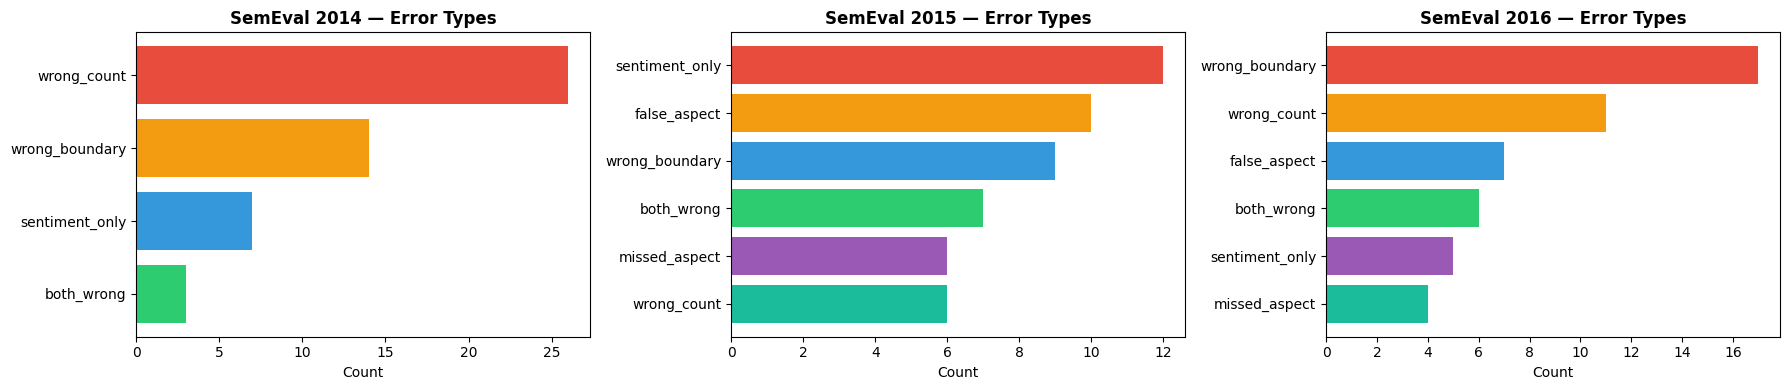

In [9]:
# Error type distribution chart
if all_results:
    n_datasets = len(all_results)
    fig, axes = plt.subplots(1, n_datasets, figsize=(6 * n_datasets, 4))
    if n_datasets == 1:
        axes = [axes]
    
    colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6', '#1abc9c']
    
    for ax, (year, result) in zip(axes, all_results.items()):
        if result.errors:
            error_summary = get_error_summary(result.errors)
            ax.barh(
                error_summary['Error Type'],
                error_summary['Count'],
                color=colors[:len(error_summary)],
            )
            ax.set_title(f'SemEval {year} — Error Types', fontweight='bold')
            ax.set_xlabel('Count')
            ax.invert_yaxis()
        else:
            ax.text(0.5, 0.5, 'No errors', ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    plt.savefig('outputs/plots/error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. SOTA Comparison

In [10]:
for year, result in all_results.items():
    print(f'\n--- SOTA Comparison: SemEval {year} ---')
    our_metrics = {
        'ate_f1': result.ate.strict_f1,
        'asc_acc': result.asc.accuracy,
        'asc_f1': result.asc.macro_f1,
    }
    sota_df = get_sota_comparison_df(year, our_metrics)
    display(sota_df.style.set_caption(f'SemEval {year} — SOTA Comparison'))
    print()


--- SOTA Comparison: SemEval 2014 ---


,Model,ATE F1,ASC Acc,ASC F1
0,BERT-SPC,—,84.46,76.98
1,LCF-BERT,—,87.14,80.31
2,DualGCN-BERT,83.02,84.27,78.08
3,GRACE,87.93,—,72.30
4,InstructABSA,86.63,90.18,83.50
5,SPAN-ASTE,86.71,—,—
6,MVP,85.30,—,75.41
7,⭐ Ours (ModernBERT-RGAT),78.35,76.10,56.73




--- SOTA Comparison: SemEval 2015 ---


,Model,ATE F1,ASC Acc,ASC F1
0,BERT-SPC,—,81.18,60.32
1,LCF-BERT,—,82.45,63.89
2,DualGCN-BERT,67.89,81.16,62.32
3,GRACE,72.75,—,57.63
4,InstructABSA,74.83,85.22,68.10
5,⭐ Ours (ModernBERT-RGAT),67.96,83.84,59.54




--- SOTA Comparison: SemEval 2016 ---


,Model,ATE F1,ASC Acc,ASC F1
0,BERT-SPC,—,87.89,66.75
1,LCF-BERT,—,89.72,73.18
2,DualGCN-BERT,74.81,88.36,70.92
3,GRACE,78.93,—,66.38
4,InstructABSA,79.45,91.04,76.38
5,⭐ Ours (ModernBERT-RGAT),67.20,87.79,65.28


## 8. Training History Visualization

  ✅ Loaded history for 2014 (11 epochs)
  ✅ Loaded history for 2015 (18 epochs)
  ✅ Loaded history for 2016 (17 epochs)


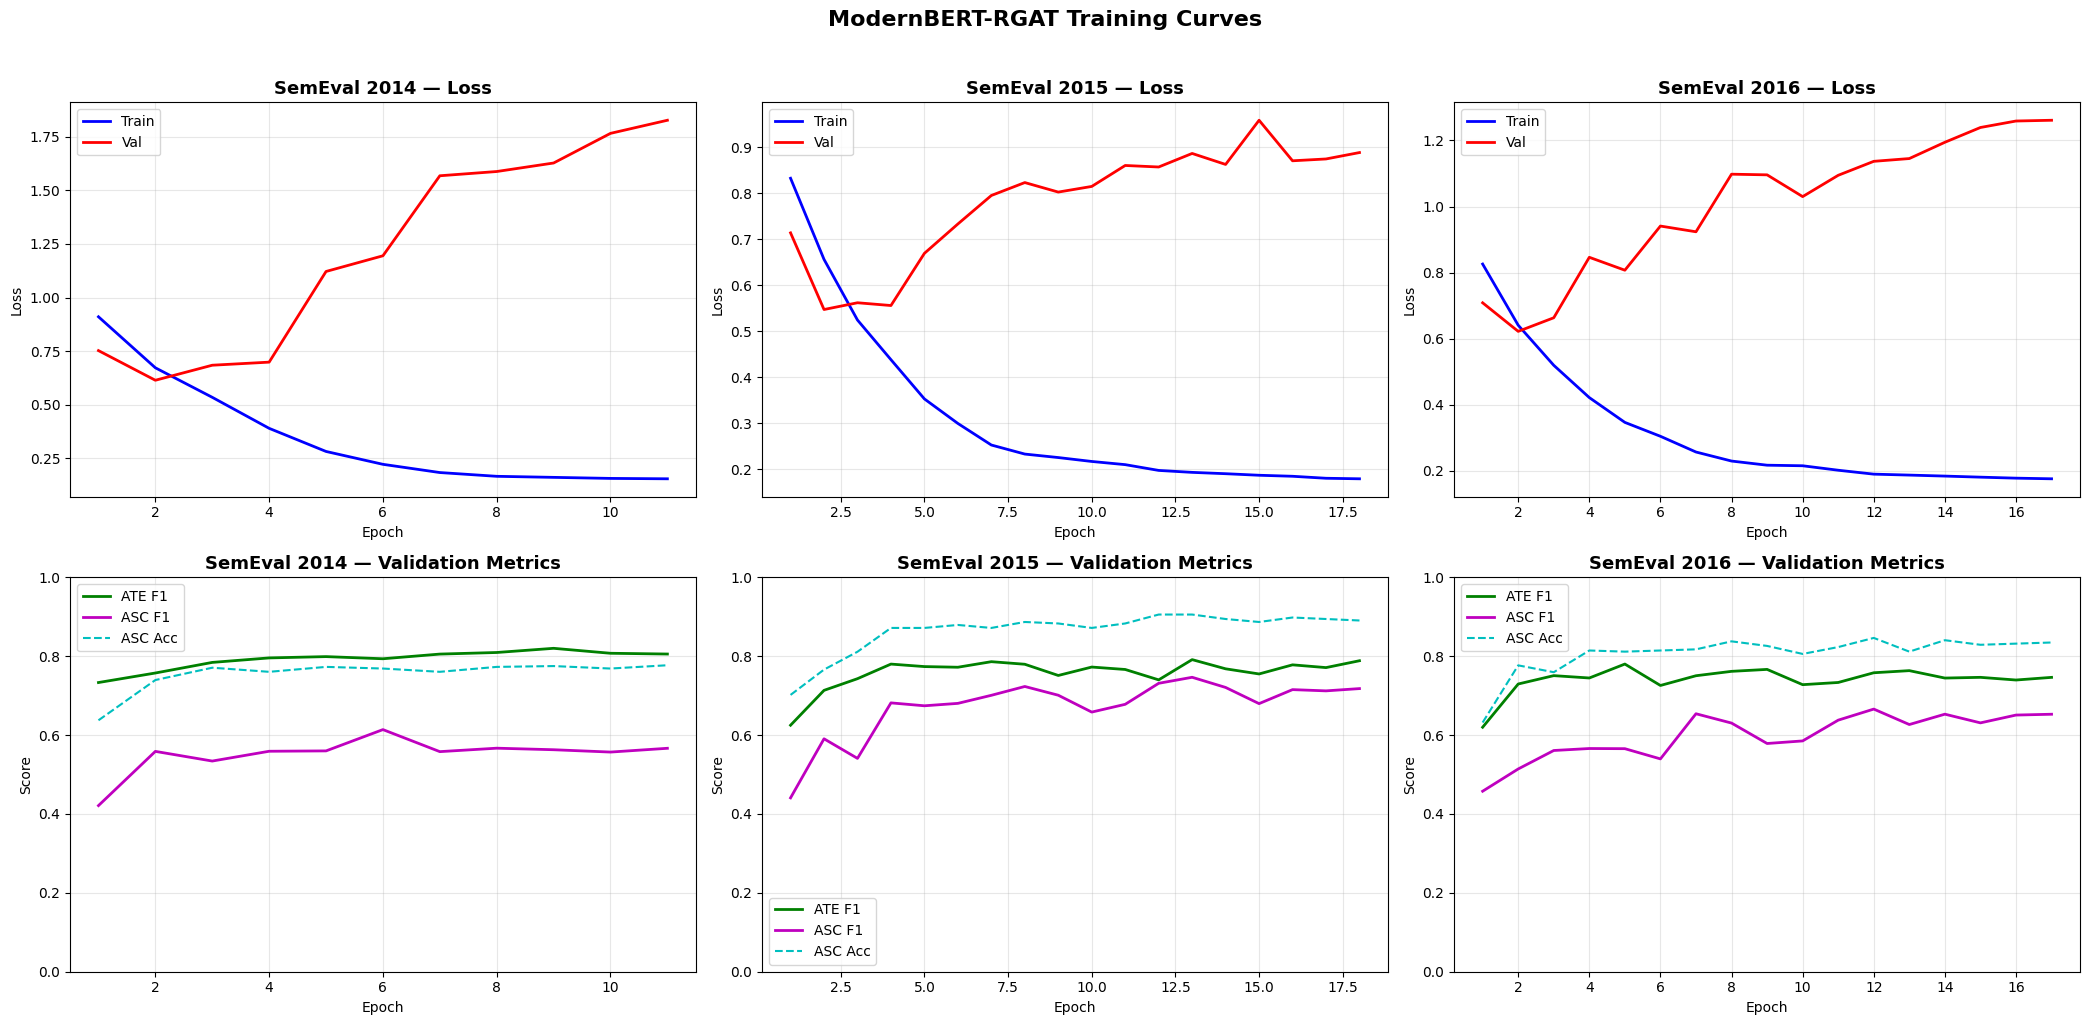

In [11]:
# Load and plot training histories if available
history_files = {}
for year in available_years:
    history_path = os.path.join(ckpt_dir, f'history_{year}.json')
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            history_files[year] = json.load(f)
        print(f'  ✅ Loaded history for {year} ({len(history_files[year].get("train_loss", []))} epochs)')
    else:
        print(f'  ❌ No history file for {year}')

if history_files:
    n = len(history_files)
    fig, axes = plt.subplots(2, n, figsize=(7 * n, 10))
    if n == 1:
        axes = axes.reshape(-1, 1)
    
    for col, (year, history) in enumerate(history_files.items()):
        epochs = range(1, len(history['train_loss']) + 1)
        
        # Loss plot
        ax = axes[0, col]
        ax.plot(epochs, history['train_loss'], 'b-', label='Train', lw=2)
        ax.plot(epochs, history['val_loss'], 'r-', label='Val', lw=2)
        ax.set_title(f'SemEval {year} — Loss', fontweight='bold', fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Metrics plot
        ax = axes[1, col]
        if 'val_ate_f1' in history:
            ax.plot(epochs, history['val_ate_f1'], 'g-', label='ATE F1', lw=2)
        if 'val_asc_f1' in history:
            ax.plot(epochs, history['val_asc_f1'], 'm-', label='ASC F1', lw=2)
        if 'val_asc_accuracy' in history:
            ax.plot(epochs, history['val_asc_accuracy'], 'c--', label='ASC Acc', lw=1.5)
        ax.set_title(f'SemEval {year} — Validation Metrics', fontweight='bold', fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Score')
        ax.legend()
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('ModernBERT-RGAT Training Curves', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('outputs/plots/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No training history files found.')

## 9. Save All Results

In [12]:
if all_results:
    save_evaluation_results(all_results)
    
    # Also save a human-readable summary
    summary_rows = []
    for year, result in all_results.items():
        summary_rows.append({
            'Dataset': f'SemEval {year}',
            'Samples': result.num_samples,
            'ATE Strict F1': round(result.ate.strict_f1, 4),
            'ATE Partial F1': round(result.ate.partial_f1, 4),
            'ASC Accuracy': round(result.asc.accuracy, 4),
            'ASC Macro F1': round(result.asc.macro_f1, 4),
            'Combined F1': round(result.combined_f1, 4),
        })
    
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv('outputs/results/evaluation_summary.csv', index=False)
    print('\n  Results saved to outputs/results/')
    display(summary_df)
else:
    print('No results to save.')

  Saved: outputs/results/metrics_2014.json
  Saved: outputs/results/metrics_2015.json
  Saved: outputs/results/metrics_2016.json
  Saved: outputs/results/evaluation_summary.json

  Results saved to outputs/results/


,Dataset,Samples,ATE Strict F1,ATE Partial F1,ASC Accuracy,ASC Macro F1,Combined F1
0,SemEval 2014,544,0.7835,0.8645,0.7610,0.5673,0.6754
1,SemEval 2015,297,0.6796,0.7494,0.8384,0.5954,0.6375
2,SemEval 2016,344,0.6720,0.7790,0.8779,0.6528,0.6624


## 10. RGAT Relation Importance (Interpretability)

/tmp/ipykernel_510339/2523741863.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


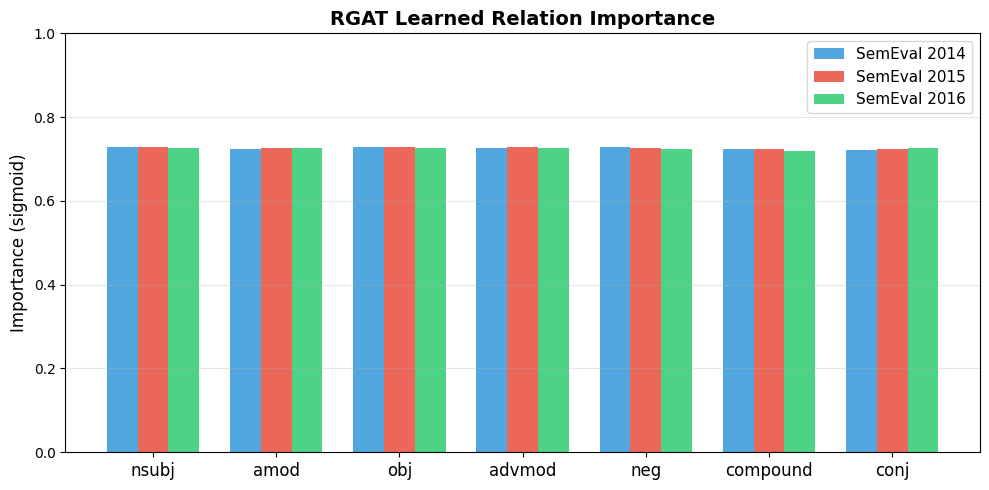


  SemEval 2014:
    nsubj     : 0.7285  #####################
    neg       : 0.7285  #####################
    obj       : 0.7277  #####################
    advmod    : 0.7270  #####################
    compound  : 0.7248  #####################
    amod      : 0.7238  #####################
    conj      : 0.7222  #####################

  SemEval 2015:
    advmod    : 0.7280  #####################
    nsubj     : 0.7279  #####################
    obj       : 0.7279  #####################
    amod      : 0.7266  #####################
    neg       : 0.7262  #####################
    conj      : 0.7240  #####################
    compound  : 0.7239  #####################

  SemEval 2016:
    nsubj     : 0.7273  #####################
    amod      : 0.7272  #####################
    obj       : 0.7268  #####################
    advmod    : 0.7259  #####################
    conj      : 0.7252  #####################
    neg       : 0.7250  #####################
    compound  : 0.7193  #####

In [13]:
rel_names = ['nsubj', 'amod', 'obj', 'advmod', 'neg', 'compound', 'conj']
rel_data = {}

for year in available_years:
    ckpt_path = os.path.join(ckpt_dir, f'best_model_{year}.pt')
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location='cpu')
        sd = ckpt['model_state_dict']
        key = 'rgat.relation_importance'
        if key in sd:
            weights = torch.sigmoid(sd[key]).tolist()
            rel_data[year] = weights

if rel_data:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(rel_names))
    width = 0.25
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    for i, (year, weights) in enumerate(rel_data.items()):
        ax.bar(x + i * width, weights, width, label=f'SemEval {year}', color=colors[i], alpha=0.85)
    
    ax.set_xticks(x + width * (len(rel_data) - 1) / 2)
    ax.set_xticklabels(rel_names, fontsize=12)
    ax.set_ylabel('Importance (sigmoid)', fontsize=12)
    ax.set_title('RGAT Learned Relation Importance', fontweight='bold', fontsize=14)
    ax.legend(fontsize=11)
    ax.set_ylim(0, 1)
    ax.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('outputs/plots/relation_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print table
    for year, weights in rel_data.items():
        print(f'\n  SemEval {year}:')
        for name, w in sorted(zip(rel_names, weights), key=lambda x: -x[1]):
            bar = '#' * int(w * 30)
            print(f'    {name:10s}: {w:.4f}  {bar}')
else:
    print('No checkpoints found for relation importance analysis.')

---

## Phase 5 Summary

| Component | Status |
|-----------|--------|
| ATE: Strict F1, Partial F1, Token F1 | Done |
| ASC: Accuracy, Per-class F1, Confusion Matrix | Done |
| Combined ATE+ASC Score | Done |
| Error Analysis (type classification) | Done |
| SOTA Comparison Table | Done |
| RGAT Interpretability (relation weights) | Done |
| Results saved to outputs/results/ | Done |

**Next step:** Phase 6 - Inference & Demo

> **Note:** When GPU is ready, retrain with full fine-tuning (all 22 BERT layers) and re-run this notebook for updated metrics.